# Examen Práctico — Primer Parcial
## Tópicos de Big Data

**Instrucciones generales**

- Este notebook es tu entregable. Complétalo en orden, sin borrar los enunciados.
- Al final debes subir este archivo (`.ipynb`) al repositorio de GitHub del curso, en la carpeta correspondiente a tu nombre/usuario.
- Se evaluará tanto el código (que corra sin errores, de arriba hacia abajo) como tus interpretaciones escritas en las celdas de texto marcadas como *"Interpretación"*.
- Cada quien trabaja con **un dataset distinto**, asignado por la profesora. No copies celdas de un compañero con un dataset diferente: aunque las preguntas se parecen, los datos y las columnas no son las mismas.


## 0. Datos del alumno

Completa la siguiente celda con tus datos y el nombre del dataset que te fue asignado.

In [3]:
# --- COMPLETA CON TUS DATOS ---
NOMBRE = "Paulina González Ramírez"            # Tu nombre completo
MATRICULA = "81678"         # Tu matrícula o número de cuenta
DATASET_ASIGNADO = "homicidios"  # Debe ser uno de: "alcohol", "migracion", "desnutricion", "pib", "homicidios"

print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")


Alumno: Paulina González Ramírez
Matrícula: 81678
Dataset asignado: homicidios


## 1. Configuración del entorno virtual (Visual Studio Code)

Antes de instalar librerías directamente en tu sistema, es una buena práctica crear un
**entorno virtual** exclusivo para este examen. Esto evita conflictos de versiones con
otros proyectos y hace que tu entorno de trabajo sea reproducible.

**Requisitos previos en VS Code:** ten instaladas las extensiones oficiales **"Python"**
y **"Jupyter"** (ambas de Microsoft), disponibles en la pestaña de Extensiones (ícono de
cuadritos en la barra lateral izquierda, o `Ctrl+Shift+X` / `Cmd+Shift+X`).

Abre una terminal **dentro de VS Code** (menú **Terminal → New Terminal**, o
`` Ctrl+ñ ``/`` Ctrl+` ``) y verifica que estés ubicado en la carpeta de tu repositorio
del curso (donde vas a guardar este notebook).

### Windows (PowerShell, terminal integrada de VS Code)

```powershell
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python -m venv .venv

# 2. Activar el entorno virtual
.venv\Scripts\Activate.ps1

# Si PowerShell bloquea la ejecución de scripts, ejecuta una sola vez:
#   Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
# y vuelve a intentar activar el entorno.

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

### macOS / Linux (terminal integrada de VS Code, bash o zsh)

```bash
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python3 -m venv .venv

# 2. Activar el entorno virtual
source .venv/bin/activate

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

> **Nota:** usamos el nombre `.venv` (con punto) porque VS Code lo detecta automáticamente
> dentro de la carpeta del proyecto. Si usas Anaconda/Miniconda en lugar de `venv`, el
> equivalente es:
> ```bash
> conda create -n examen-bigdata python=3.11 pandas numpy ipykernel matplotlib requests -y
> conda activate examen-bigdata
> ```

### Seleccionar el entorno virtual como kernel en VS Code

A diferencia de Jupyter Notebook/Lab, en VS Code **no necesitas registrar el entorno
manualmente con `ipykernel install`**: basta con tener el paquete `ipykernel` instalado
en el entorno (ya quedó instalado en el paso anterior) y seleccionar ese entorno
directamente como kernel del notebook.

1. Abre este archivo `.ipynb` en VS Code.
2. En la esquina superior derecha del notebook, haz clic en el selector de kernel
   (dice algo como **"Select Kernel"** la primera vez).
3. Elige **"Python Environments..."** y de la lista selecciona el entorno `.venv`
   que acabas de crear (debe aparecer como algo como `.venv (Python 3.x.x)` con la
   ruta de tu proyecto).
4. Si no aparece en la lista, haz clic en **"Select Another Kernel" → "Python
   Environments..."** y usa **"Enter interpreter path..."** para localizar manualmente
   el ejecutable dentro de `.venv/bin/python` (macOS/Linux) o `.venv\Scripts\python.exe`
   (Windows).
5. Verifica que quedó bien seleccionado ejecutando la celda de abajo: debe mostrar una
   ruta que contenga la carpeta `.venv` (o el nombre de tu entorno de conda), y no la
   instalación global de Python.

In [4]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.


c:\Users\paugo\anaconda3\python.exe


## 2. Configuración y carga de datos

La siguiente celda **no se modifica**. Contiene la configuración de los 5 datasets
posibles del examen. A partir de tu variable `DATASET_ASIGNADO` de la celda anterior,
el notebook cargará automáticamente el dataset y los metadatos que te corresponden.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "alcohol": {
        "csv": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "alcohol__consumers_past_12_months__pct__age_standardized__sex_both_sexes",
        "filtro_paises": "code",       # columna a usar para filtrar países reales vs. agregados
        "descripcion": "Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio",
        "unidad": "%",
    },
    "migracion": {
        "csv": "https://ourworldindata.org/grapher/migrant-populations.csv?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "meta": "https://ourworldindata.org/grapher/migrant-populations.metadata.json?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "valor_col": "immigrants_all",
        "filtro_paises": "owid_region",
        "descripcion": "Numero total de inmigrantes internacionales residiendo en el pais",
        "unidad": "personas",
    },
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    },
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    },
    "homicidios": {
        "csv": "https://ourworldindata.org/grapher/homicides-unodc.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/homicides-unodc.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "value__category_total__sex_total__age_total__unit_of_measurement_counts",
        "filtro_paises": "owid_region",
        "descripcion": "Numero de homicidios intencionales por anio",
        "unidad": "homicidios",
    },
}

assert DATASET_ASIGNADO in DATASETS, (
    "DATASET_ASIGNADO debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS[DATASET_ASIGNADO]
print(f"Cargando dataset: {DATASET_ASIGNADO}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")


Cargando dataset: homicidios
Descripcion: Numero de homicidios intencionales por anio (homicidios)


In [6]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})


In [7]:
df.head(25)

,entity,code,year,valor,owid_region
0,Afghanistan,AFG,2009,1115.000,Asia
1,Afghanistan,AFG,2010,983.000,Asia
2,Afghanistan,AFG,2011,1231.000,Asia
3,Afghanistan,AFG,2012,1948.000,Asia
4,Afghanistan,AFG,2015,3367.000,Asia
5,Afghanistan,AFG,2016,2318.000,Asia
6,Afghanistan,AFG,2017,2424.000,Asia
7,Afghanistan,AFG,2018,2474.000,Asia
8,Afghanistan,AFG,2019,2712.000,Asia
9,Afghanistan,AFG,2020,2570.000,Asia


## 3. Exploración inicial

Antes de responder las preguntas de análisis, explora el dataset: tipos de datos,
dimensiones, valores nulos y estadísticas descriptivas básicas.

In [8]:
# Forma del dataset (filas, columnas)
df.shape


(4914, 5)

In [9]:
# Tipos de datos e informacion general
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4914 entries, 0 to 4913
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   entity       4914 non-null   object 
 1   code         4399 non-null   object 
 2   year         4914 non-null   int64  
 3   valor        4914 non-null   float64
 4   owid_region  4220 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 192.1+ KB


In [10]:
# Estadisticas descriptivas de la columna 'valor'
df['valor'].describe()


count      4914.000000
mean       8582.853861
std       37590.820449
min           0.000000
25%          37.000000
50%         256.500000
75%        1171.968475
max      450728.880000
Name: valor, dtype: float64

In [11]:
# Conteo de valores nulos por columna
df.isnull().sum()


entity           0
code           515
year             0
valor            0
owid_region    694
dtype: int64

In [27]:
df['year'].min()

1990

In [28]:
df['year'].max()

2024

**Interpretación (2-3 líneas):** ¿qué observas sobre los valores nulos, el rango de años y el tipo de variable con la que vas a trabajar?
En la variable valor no hay nulos, pero en code hay 515 valores nulos y en owid_region hay 694 valores nulos y el tipo de variable con la que  se trabaja valor es float es decir cuneta los numeros de homiocidos, y el ramgo de números de este dataset van desde 1990 hasta 2024




## 4. Preguntas de análisis

A continuación responde las 10 preguntas. 

Cada una tiene una celda de código para su solución y, cuando aplica, 
una celda de texto para tu interpretación. Recuerda que tu
dataset (`DATASET_ASIGNADO`) puede o no tener la columna `owid_region`; revisa el
diccionario `DATASETS` de la celda de configuración para saber qué columna (`code` u
`owid_region`) te toca usar para distinguir países reales de agregados (continentes,
"World", grupos de ingreso, etc.).

### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [12]:
# Pregunta 1
df_paises = df[df[config["filtro_paises"]].notnull()].copy()
print("Paises distintos:", df_paises['entity'].nunique())

anio_reciente = df_paises['year'].max()
datos_recientes = df_paises[df_paises['year'] == anio_reciente]

top10_mayor = datos_recientes.sort_values('valor', ascending=False).head(10)
top10_menor = datos_recientes.sort_values('valor', ascending=True).head(10)

print(f"\nTop 10 con mayor valor ({anio_reciente}):")
print(top10_mayor[['entity', 'valor']])

print(f"\nTop 10 con menor valor ({anio_reciente}):")
print(top10_menor[['entity', 'valor']])


Paises distintos: 200

Top 10 con mayor valor (2024):
           entity    valor
3685       Russia  11327.0
1596       France    897.0
2908      Morocco    635.0
3583  Puerto Rico    489.0
3652      Romania    213.0
418    Azerbaijan    206.0
2836     Mongolia    196.0
68        Albania     49.0
1140       Cyprus     13.0
1692    Gibraltar      0.0

Top 10 con menor valor (2024):
           entity    valor
1692    Gibraltar      0.0
1140       Cyprus     13.0
68        Albania     49.0
2836     Mongolia    196.0
418    Azerbaijan    206.0
3652      Romania    213.0
3583  Puerto Rico    489.0
2908      Morocco    635.0
1596       France    897.0
3685       Russia  11327.0


**Interpretación:**

*Se observa que hay 200  paises distitnos y despues podemos ver los diez paises con mayor y mneor valior de homicidios, el pais con menor valor de homicidios es Gibraltar con 0 y el de mayor es Rusia con 11327 * y con el .max pude ver que el añi con mas alto valor fue 2024.

### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [17]:
# Pregunta 2
paises_2 = ['Mexico', 'Colombia']
df_dos = df_paises[df_paises['entity'].isin(paises_2)]

# Rango de años en comun para ambos paises
anio_min_comun = df_dos.groupby('entity')['year'].min().max()
anio_max_comun = df_dos.groupby('entity')['year'].max().min()

df_dos_rango = df_dos[
    (df_dos['year'] >= anio_min_comun) & (df_dos['year'] <= anio_max_comun)
]

print(f"Rango de años en comun: {anio_min_comun} - {anio_max_comun}")
df_dos_rango[['entity', 'year', 'valor']].sort_values(['entity', 'year'])



Rango de años en comun: 1990 - 2023


,entity,year,valor
969,Colombia,1990,24330.0
970,Colombia,1991,28424.0
971,Colombia,1992,28184.0
972,Colombia,1993,28441.0
973,Colombia,1994,27079.0
...,...,...,...
2747,Mexico,2019,36661.0
2748,Mexico,2020,36773.0
2749,Mexico,2021,35700.0
2750,Mexico,2022,33287.0


### Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [18]:
# Pregunta 3
paises_3 = ['Mexico', 'Brazil', 'Germany', 'Australia', 'Nigeria']
df_3 = df_paises[df_paises['entity'].isin(paises_3)]

# Nos quedamos con el año mas reciente disponible para cada pais
ultimo_anio_por_pais = df_3.groupby('entity')['year'].transform('max')
df_3_reciente = df_3[df_3['year'] == ultimo_anio_por_pais]

df_3_ordenado = df_3_reciente[['entity', 'year', 'valor']].sort_values(
    'valor', ascending=False
)
print(df_3_ordenado.to_string(index=False))

pais_max = df_3_ordenado.iloc[0]
pais_min = df_3_ordenado.iloc[-1]
diferencia = pais_max['valor'] - pais_min['valor']

print(f"\nPais con mayor valor: {pais_max['entity']} ({pais_max['valor']}, año {pais_max['year']})")
print(f"Pais con menor valor: {pais_min['entity']} ({pais_min['valor']}, año {pais_min['year']})")
print(f"Diferencia: {diferencia}")


   entity  year   valor
   Brazil  2023 40698.0
  Nigeria  2023 35884.0
   Mexico  2023 32252.0
  Germany  2023   770.0
Australia  2023   226.0

Pais con mayor valor: Brazil (40698.0, año 2023)
Pais con menor valor: Australia (226.0, año 2023)
Diferencia: 40472.0


**Interpretación:**

*Después de analizar estos 5 paises que seleccione note que el pais con más homicidios es Brazil con 40698 en 2023 y el de menor es Australia con 226 en 2023*

### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [19]:
# Pregunta 4
latinoamerica = ['Mexico', 'Colombia', 'Argentina']
# Vietnam no cuenta con datos disponibles en este dataset, se sustituyo por India
asia = ['China', 'Japan', 'India']

df_latam = df_paises[df_paises['entity'].isin(latinoamerica)]
df_asia = df_paises[df_paises['entity'].isin(asia)]

ultimo_latam = df_latam.groupby('entity')['year'].transform('max')
ultimo_asia = df_asia.groupby('entity')['year'].transform('max')

df_latam_reciente = df_latam[df_latam['year'] == ultimo_latam]
df_asia_reciente = df_asia[df_asia['year'] == ultimo_asia]

promedio_latam = df_latam_reciente['valor'].mean()
promedio_asia = df_asia_reciente['valor'].mean()

print("Latinoamerica (año mas reciente por pais):")
print(df_latam_reciente[['entity', 'year', 'valor']].to_string(index=False))
print(f"Promedio Latinoamerica: {promedio_latam:.2f}")

print("\nAsia (año mas reciente por pais):")
print(df_asia_reciente[['entity', 'year', 'valor']].to_string(index=False))
print(f"Promedio Asia: {promedio_asia:.2f}")


Latinoamerica (año mas reciente por pais):
   entity  year   valor
Argentina  2023  2046.0
 Colombia  2023 13035.0
   Mexico  2023 32252.0
Promedio Latinoamerica: 15777.67

Asia (año mas reciente por pais):
entity  year   valor
 China  2020  7157.0
 India  2022 40130.0
 Japan  2023   285.0
Promedio Asia: 15857.33


**Interpretación:**

*Interpretación:
Aunque los promediosde ambos son muy similares 15777 en Latinoamérica vs 15857 en Asia, el origen de las cifras es distinto. En Asia, el promedio elevado por el tamaño poblacional de India 40,130, mientras que Japón registra cifras mínimas 285; en Latinoamérica, con volúmenes significativos en países como México 32,252 y Colombia 13,035.* 

### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

In [20]:
# Pregunta 5
pais_5 = 'Colombia'
df_pais5 = df_paises[df_paises['entity'] == pais_5].sort_values('year')

anio_max_valor = df_pais5.loc[df_pais5['valor'].idxmax(), 'year']
anio_min_valor = df_pais5.loc[df_pais5['valor'].idxmin(), 'year']

print(f"Pais analizado: {pais_5}")
print(f"Año con el valor maximo: {anio_max_valor} ({df_pais5['valor'].max()})")
print(f"Año con el valor minimo: {anio_min_valor} ({df_pais5['valor'].min()})")

valor_primer_anio = df_pais5.iloc[0]['valor']
valor_ultimo_anio = df_pais5.iloc[-1]['valor']
print(f"Valor en el primer año disponible ({df_pais5.iloc[0]['year']}): {valor_primer_anio}")
print(f"Valor en el ultimo año disponible ({df_pais5.iloc[-1]['year']}): {valor_ultimo_anio}")


Pais analizado: Colombia
Año con el valor maximo: 1993 (28441.0)
Año con el valor minimo: 2020 (11464.0)
Valor en el primer año disponible (1990): 24330.0
Valor en el ultimo año disponible (2023): 13035.0


**Interpretación:**

*eñegi colombia y los resultados que obtuve fueron que el año con el valor maximo fue 1993 con 28441.0, el año con el valor minimo es 2020com 11464.0, y la tendencia es Decreciente ya que pasó de 24,330.0 en 1990 a 13,035.0 en 2023

### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

In [21]:
# Pregunta 6
df_mex = df_paises[df_paises['entity'] == 'Mexico'].sort_values('year')

valor_inicial = df_mex.iloc[0]['valor']
valor_final = df_mex.iloc[-1]['valor']
anio_inicial = df_mex.iloc[0]['year']
anio_final = df_mex.iloc[-1]['year']

cambio_pct = (valor_final - valor_inicial) / valor_inicial * 100

print(f"Mexico paso de {valor_inicial} homicidios en {anio_inicial} a {valor_final} en {anio_final}")
print(f"Cambio porcentual: {cambio_pct:.2f}%")


Mexico paso de 14493.0 homicidios en 1990 a 32252.0 en 2023
Cambio porcentual: 122.54%


**Interpretación:**

*Interpretación:
México presenta un incremento relativo drástico del 122.54% al pasar de 14,493 homicidios en 1990 a 32,252 en 2023. Yo supongo que este incremento de hocmicios se debe al narcotrafico*

### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

In [22]:
# Pregunta 7
anio_reciente = df_paises['year'].max()
valores_recientes = df_paises[df_paises['year'] == anio_reciente]['valor'].values
valores_recientes = valores_recientes[~np.isnan(valores_recientes)]

media = np.mean(valores_recientes)
mediana = np.median(valores_recientes)
desviacion = np.std(valores_recientes)

print(f"Año analizado: {anio_reciente}")
print(f"Numero de paises con dato en ese año: {len(valores_recientes)}")
print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Desviacion estandar: {desviacion:.2f}")


Año analizado: 2024
Numero de paises con dato en ese año: 10
Media: 1402.50
Mediana: 209.50
Desviacion estandar: 3319.74


**Interpretación:**

*Interpretación:
Para el año 2024 la media (1,402.50) supera por mucho a la mediana (209.50) debido a atípicos. La elevada desviación estándar 3,319.74 confirma una alta dispersion de los datos dispersión y variabilidad en los datos*

### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

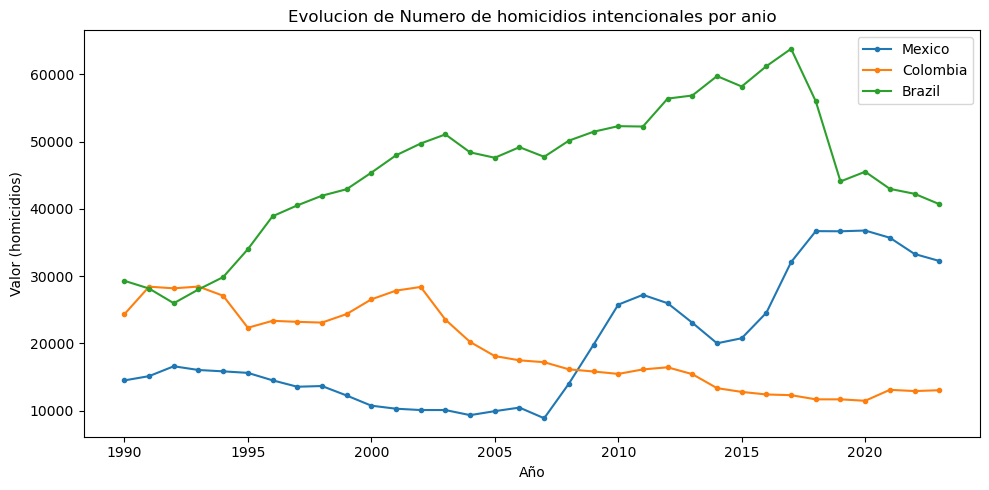

In [23]:
# Pregunta 8
paises_8 = ['Mexico', 'Colombia', 'Brazil']

plt.figure(figsize=(10, 5))
for pais in paises_8:
    datos_pais = df_paises[df_paises['entity'] == pais].sort_values('year')
    plt.plot(datos_pais['year'], datos_pais['valor'], marker='o', markersize=3, label=pais)

plt.xlabel('Año')
plt.ylabel(f"Valor ({config['unidad']})")
plt.title(f"Evolucion de {config['descripcion']}")
plt.legend()
plt.tight_layout()
plt.show()


**Interpretación:**

*Interpretación:
La gráfica nos da entender q Brasil encabeza históricamente el volumen absoluto con un pico cercano a 2017 seguido de una reducción; Colombia refleja un descenso sostenido y continuo desde inicios de los 2000; mientras que México muestra un incremento acelerado a partir de 2008, estabilizándose en niveles elevados en los ultimos 10 años*

### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

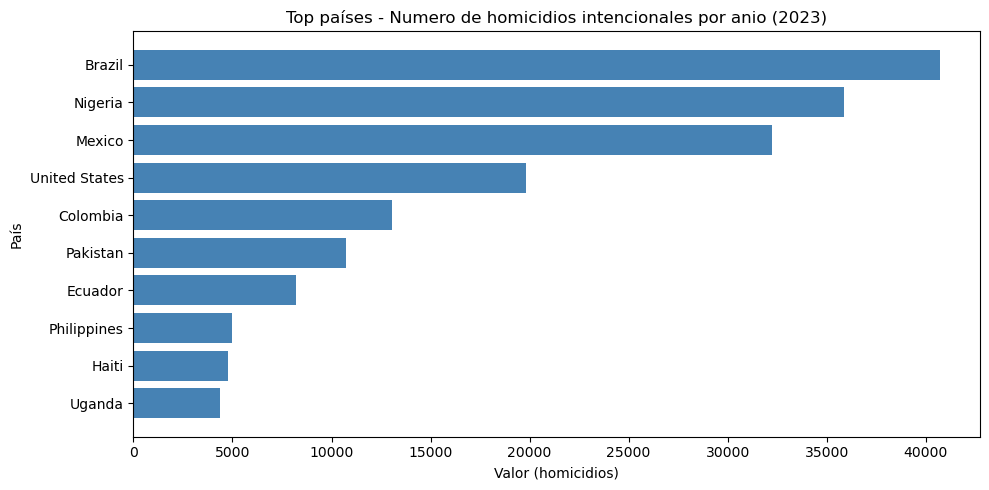

In [25]:
# Pregunta 9
# Tu codigo aqui
ANIO_NACIMIENTO = 2005

for anio_consultado in [ANIO_NACIMIENTO, 2023]:
    top = (
        df_paises[df_paises['year'] == anio_consultado]
        .sort_values('valor', ascending=False)
        .head(10)
    )

top = (
    df_paises[df_paises['year'] == anio_consultado]
    .sort_values('valor', ascending=False)
    .head(10)
)
# Grafica de barras horizontales
plt.figure(figsize=(10, 5))
plt.barh(top['entity'], top['valor'], color='steelblue')

plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top países - {config['descripcion']} ({anio_consultado})")

plt.gca().invert_yaxis()  # para que el país con el valor mas alto quede arriba
plt.tight_layout()
plt.show()


**Interpretación:**

*Brazil una vez mas tiene más homciios y el pais ocn menos homicidios es uganda*

## 5. Conclusión general

En 5 - 10 líneas, resume qué aprendiste sobre el dataset que te tocó trabajar: ¿qué
patrones encontraste?, ¿qué limitaciones tiene la información (por ejemplo, valores
absolutos sin normalizar por población, datos faltantes, etc.)?, ¿qué harías distinto si
tuvieras más tiempo?

*En este dataset aprendí a analizar cómo ha cambiado la violencia en distintos países a lo largo del tiempo. Noté patrones muy claros: países como Brasil y México han tenido incrementos muy fuertes en sus cifras a partir de ciertos años, mientras que otros como Colombia han logrado bajar sus números de forma constante. Sin embargo, la mayor limitación de los datos es que se presentan en el número total de homicidios y no por cada 100,000 habitantes esto es engañoso porque países muy poblados como India o Brasil siempre se ven peor que países pequeños, aunque su riesgo por persona sea distinto. Además, faltan muas datos recientes *

## 6. Entrega

1. Verifica que el notebook corra completo de arriba hacia abajo sin errores (`Kernel > Restart & Run All`).
2. Guarda el archivo con el nombre: `apellido_nombre_examen_parcial1.ipynb`.
3. Súbelo al repositorio de GitHub del curso, en una carpeta para este examen.
4. Comparte el link de tu repo y envia una copia del notebook por teams.
